In [3]:
# ============================================================
# AI Credit Risk Intelligence System
# Step 1: Setup + Load Raw German Credit Dataset
# ============================================================

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Load raw dataset
file_path = "/content/sample_data/german.data"

column_names = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "present_residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

df = pd.read_csv(file_path, sep=" ", header=None, names=column_names)

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
# Basic dataset check

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
display(df.isnull().sum())

print("\nTarget distribution:")
display(df["target"].value_counts())

print("\nTarget distribution percentage:")
display(df["target"].value_counts(normalize=True) * 100)

Rows: 1000
Columns: 21

Missing values:


,0
checking_account_status,0
duration_months,0
credit_history,0
purpose,0
credit_amount,0
savings_account,0
employment_since,0
installment_rate,0
personal_status_sex,0
other_debtors,0



Target distribution:


,count
target,
1,700
2,300



Target distribution percentage:


,proportion
target,
1,70.0
2,30.0


In [5]:
# ============================================================
# Step 2: Decode German Credit Banking Codes
# ============================================================

checking_map = {
    "A11": "< 0 DM",
    "A12": "0 - 200 DM",
    "A13": "> 200 DM",
    "A14": "No Checking Account"
}

credit_history_map = {
    "A30": "No Credits Taken",
    "A31": "All Credits Paid Back",
    "A32": "Existing Credits Paid Back",
    "A33": "Delay in Paying Past Credits",
    "A34": "Critical Account"
}

purpose_map = {
    "A40": "Car (New)",
    "A41": "Car (Used)",
    "A42": "Furniture/Equipment",
    "A43": "Radio/TV",
    "A44": "Domestic Appliances",
    "A45": "Repairs",
    "A46": "Education",
    "A47": "Vacation",
    "A48": "Retraining",
    "A49": "Business",
    "A410": "Others"
}

savings_map = {
    "A61": "< 100 DM",
    "A62": "100 - 500 DM",
    "A63": "500 - 1000 DM",
    "A64": "> 1000 DM",
    "A65": "Unknown / None"
}

employment_map = {
    "A71": "Unemployed",
    "A72": "< 1 Year",
    "A73": "1 - 4 Years",
    "A74": "4 - 7 Years",
    "A75": "> 7 Years"
}

personal_map = {
    "A91": "Male Divorced/Separated",
    "A92": "Female Divorced/Married",
    "A93": "Male Single",
    "A94": "Male Married/Widowed",
    "A95": "Female Single"
}

debtors_map = {
    "A101": "None",
    "A102": "Co-applicant",
    "A103": "Guarantor"
}

property_map = {
    "A121": "Real Estate",
    "A122": "Building Society Savings",
    "A123": "Car or Other",
    "A124": "Unknown / None"
}

installment_plan_map = {
    "A141": "Bank",
    "A142": "Stores",
    "A143": "None"
}

housing_map = {
    "A151": "Rent",
    "A152": "Own",
    "A153": "For Free"
}

job_map = {
    "A171": "Unemployed/Unskilled Non-Resident",
    "A172": "Unskilled Resident",
    "A173": "Skilled Employee",
    "A174": "Highly Skilled / Management"
}

telephone_map = {
    "A191": "No Telephone",
    "A192": "Has Telephone"
}

foreign_map = {
    "A201": "Yes",
    "A202": "No"
}

# Apply mappings
df["checking_account_status"] = df["checking_account_status"].map(checking_map)
df["credit_history"] = df["credit_history"].map(credit_history_map)
df["purpose"] = df["purpose"].map(purpose_map)
df["savings_account"] = df["savings_account"].map(savings_map)
df["employment_since"] = df["employment_since"].map(employment_map)
df["personal_status_sex"] = df["personal_status_sex"].map(personal_map)
df["other_debtors"] = df["other_debtors"].map(debtors_map)
df["property"] = df["property"].map(property_map)
df["other_installment_plans"] = df["other_installment_plans"].map(installment_plan_map)
df["housing"] = df["housing"].map(housing_map)
df["job"] = df["job"].map(job_map)
df["telephone"] = df["telephone"].map(telephone_map)
df["foreign_worker"] = df["foreign_worker"].map(foreign_map)

# Convert target to business label
df["target"] = df["target"].map({1: "Good Credit", 2: "Bad Credit"})

print("All banking categorical codes decoded successfully.")
df.head()

All banking categorical codes decoded successfully.


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,< 0 DM,6,Critical Account,Radio/TV,1169,Unknown / None,> 7 Years,4,Male Single,None,4,Real Estate,67,None,Own,2,Skilled Employee,1,Has Telephone,Yes,Good Credit
1,0 - 200 DM,48,Existing Credits Paid Back,Radio/TV,5951,< 100 DM,1 - 4 Years,2,Female Divorced/Married,None,2,Real Estate,22,None,Own,1,Skilled Employee,1,No Telephone,Yes,Bad Credit
2,No Checking Account,12,Critical Account,Education,2096,< 100 DM,4 - 7 Years,2,Male Single,None,3,Real Estate,49,None,Own,1,Unskilled Resident,2,No Telephone,Yes,Good Credit
3,< 0 DM,42,Existing Credits Paid Back,Furniture/Equipment,7882,< 100 DM,4 - 7 Years,2,Male Single,Guarantor,4,Building Society Savings,45,None,For Free,1,Skilled Employee,2,No Telephone,Yes,Good Credit
4,< 0 DM,24,Delay in Paying Past Credits,Car (New),4870,< 100 DM,1 - 4 Years,3,Male Single,None,4,Unknown / None,53,None,For Free,2,Skilled Employee,2,No Telephone,Yes,Bad Credit


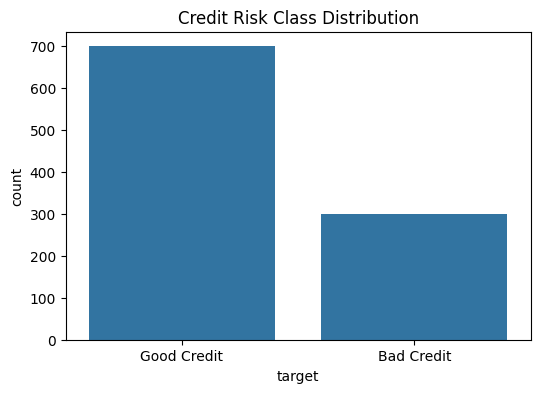

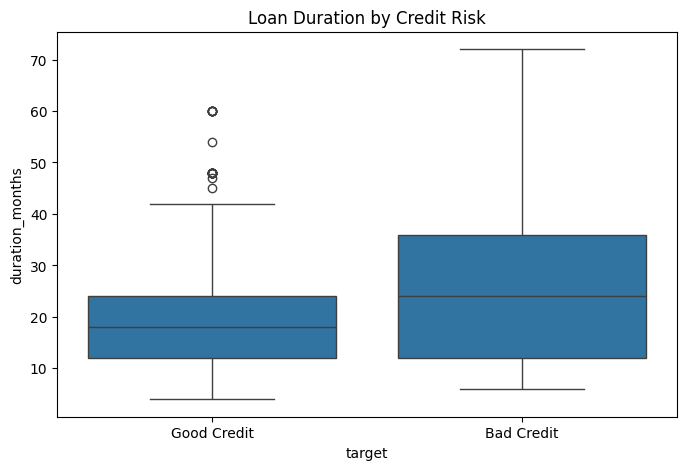

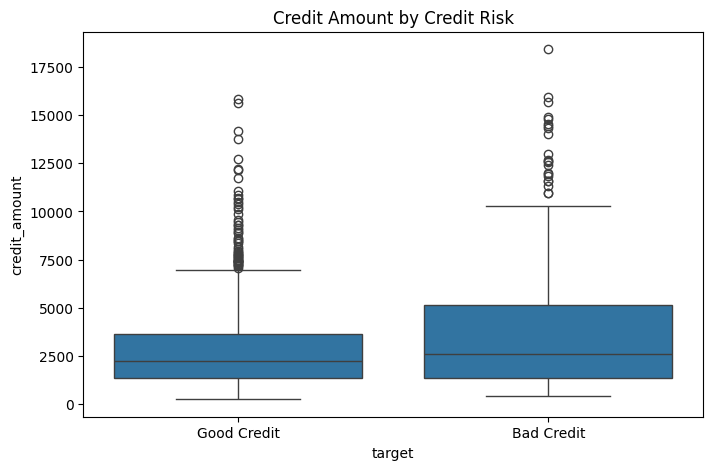

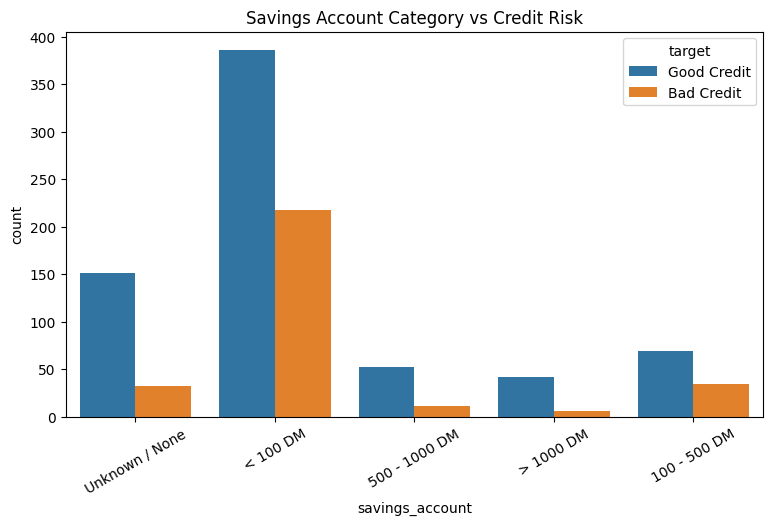

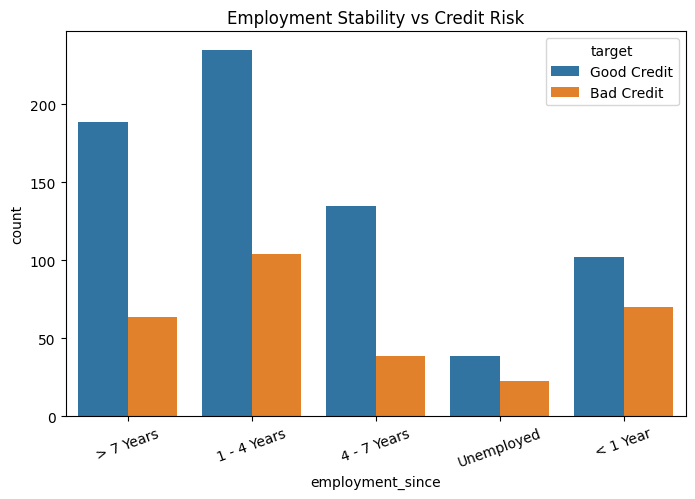

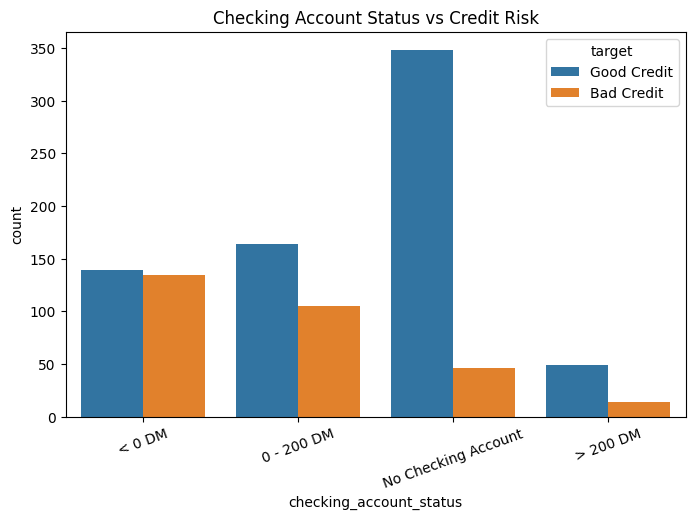

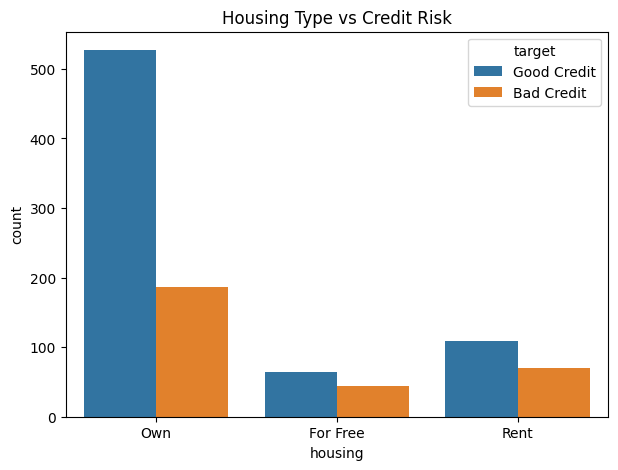

In [6]:
# ============================================================
# Step 3: Advanced Exploratory Data Analysis
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# 3.1 Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Credit Risk Class Distribution")
plt.show()

# 3.2 Loan Duration vs Credit Risk
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="duration_months", data=df)
plt.title("Loan Duration by Credit Risk")
plt.show()

# 3.3 Credit Amount vs Credit Risk
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="credit_amount", data=df)
plt.title("Credit Amount by Credit Risk")
plt.show()

# Savings Account Status vs Risk
plt.figure(figsize=(9,5))
sns.countplot(x="savings_account", hue="target", data=df)
plt.xticks(rotation=30)
plt.title("Savings Account Category vs Credit Risk")
plt.show()

# 3.5 Employment Stability vs Risk
plt.figure(figsize=(8,5))
sns.countplot(x="employment_since", hue="target", data=df)
plt.xticks(rotation=20)
plt.title("Employment Stability vs Credit Risk")
plt.show()

# 3.6 Checking Account Status vs Risk
plt.figure(figsize=(8,5))
sns.countplot(x="checking_account_status", hue="target", data=df)
plt.xticks(rotation=20)
plt.title("Checking Account Status vs Credit Risk")
plt.show()

# 3.7 Housing Type vs Risk
plt.figure(figsize=(7,5))
sns.countplot(x="housing", hue="target", data=df)
plt.title("Housing Type vs Credit Risk")
plt.show()


## Business Insight Summary from Exploratory Analysis

The exploratory analysis reveals several financially meaningful borrower patterns associated with default risk.

Applicants categorized under Bad Credit generally exhibit:

- Longer repayment durations,
- Higher requested loan amounts,
- Lower savings reserves,
- Poorer checking account liquidity,
- Less stable employment histories, and
- Lower levels of asset ownership.

These findings indicate that repayment burden, financial liquidity, and long-term economic stability are dominant behavioral indicators in creditworthiness assessment. Such patterns align closely with real-world banking intuition where financially strained applicants present elevated default uncertainty.

In [7]:
# ============================================================
# Step 4: Advanced Feature Engineering
# ============================================================

df_fe = df.copy()

# 1. Loan amount per month
df_fe["loan_amount_per_month"] = df_fe["credit_amount"] / df_fe["duration_months"]

# 2. Age groups
def age_group(age):
    if age < 25:
        return "Young Applicant"
    elif age < 35:
        return "Early Career"
    elif age < 50:
        return "Mid Career"
    else:
        return "Senior Applicant"

df_fe["age_group"] = df_fe["age"].apply(age_group)

# 3. Loan duration risk band
def duration_risk(duration):
    if duration <= 12:
        return "Short Term"
    elif duration <= 24:
        return "Medium Term"
    elif duration <= 48:
        return "Long Term"
    else:
        return "Very Long Term"

df_fe["duration_risk_band"] = df_fe["duration_months"].apply(duration_risk)

# 4. Credit amount risk band
def amount_risk(amount):
    if amount <= 1500:
        return "Low Amount"
    elif amount <= 4000:
        return "Medium Amount"
    elif amount <= 8000:
        return "High Amount"
    else:
        return "Very High Amount"

df_fe["credit_amount_risk_band"] = df_fe["credit_amount"].apply(amount_risk)

# 5. Employment strength score
employment_score_map = {
    "Unemployed": 0,
    "< 1 Year": 1,
    "1 - 4 Years": 2,
    "4 - 7 Years": 3,
    "> 7 Years": 4
}

df_fe["employment_strength_score"] = df_fe["employment_since"].map(employment_score_map)

# 6. Savings strength score
savings_score_map = {
    "< 100 DM": 0,
    "100 - 500 DM": 1,
    "500 - 1000 DM": 2,
    "> 1000 DM": 3,
    "Unknown / None": 1
}

df_fe["savings_strength_score"] = df_fe["savings_account"].map(savings_score_map)

# 7. Checking liquidity score
checking_score_map = {
    "< 0 DM": 0,
    "0 - 200 DM": 1,
    "> 200 DM": 2,
    "No Checking Account": 3
}

df_fe["checking_liquidity_score"] = df_fe["checking_account_status"].map(checking_score_map)

# 8. Asset ownership score
asset_score_map = {
    "Unknown / None": 0,
    "Car or Other": 1,
    "Building Society Savings": 2,
    "Real Estate": 3
}

df_fe["asset_strength_score"] = df_fe["property"].map(asset_score_map)

# 9. Overall financial stability index
df_fe["financial_stability_index"] = (
    df_fe["employment_strength_score"]
    + df_fe["savings_strength_score"]
    + df_fe["checking_liquidity_score"]
    + df_fe["asset_strength_score"]
)

# 10. Repayment pressure indicator
df_fe["repayment_pressure_score"] = (
    df_fe["installment_rate"] * df_fe["duration_months"]
) / df_fe["financial_stability_index"].replace(0, 1)

# 11. Binary high-risk flags
df_fe["is_high_amount"] = (df_fe["credit_amount"] > df_fe["credit_amount"].quantile(0.75)).astype(int)
df_fe["is_long_duration"] = (df_fe["duration_months"] > df_fe["duration_months"].quantile(0.75)).astype(int)
df_fe["is_low_liquidity"] = (df_fe["checking_liquidity_score"] <= 1).astype(int)
df_fe["is_low_savings"] = (df_fe["savings_strength_score"] == 0).astype(int)

print("Feature engineering completed.")
print("Original shape:", df.shape)
print("New shape:", df_fe.shape)

df_fe.head()

Feature engineering completed.
Original shape: (1000, 21)
New shape: (1000, 35)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target,loan_amount_per_month,age_group,duration_risk_band,credit_amount_risk_band,employment_strength_score,savings_strength_score,checking_liquidity_score,asset_strength_score,financial_stability_index,repayment_pressure_score,is_high_amount,is_long_duration,is_low_liquidity,is_low_savings
0,< 0 DM,6,Critical Account,Radio/TV,1169,Unknown / None,> 7 Years,4,Male Single,None,4,Real Estate,67,None,Own,2,Skilled Employee,1,Has Telephone,Yes,Good Credit,194.833333,Senior Applicant,Short Term,Low Amount,4,1,0,3,8,3.000000,0,0,1,0
1,0 - 200 DM,48,Existing Credits Paid Back,Radio/TV,5951,< 100 DM,1 - 4 Years,2,Female Divorced/Married,None,2,Real Estate,22,None,Own,1,Skilled Employee,1,No Telephone,Yes,Bad Credit,123.979167,Young Applicant,Long Term,High Amount,2,0,1,3,6,16.000000,1,1,1,1
2,No Checking Account,12,Critical Account,Education,2096,< 100 DM,4 - 7 Years,2,Male Single,None,3,Real Estate,49,None,Own,1,Unskilled Resident,2,No Telephone,Yes,Good Credit,174.666667,Mid Career,Short Term,Medium Amount,3,0,3,3,9,2.666667,0,0,0,1
3,< 0 DM,42,Existing Credits Paid Back,Furniture/Equipment,7882,< 100 DM,4 - 7 Years,2,Male Single,Guarantor,4,Building Society Savings,45,None,For Free,1,Skilled Employee,2,No Telephone,Yes,Good Credit,187.666667,Mid Career,Long Term,High Amount,3,0,0,2,5,16.800000,1,1,1,1
4,< 0 DM,24,Delay in Paying Past Credits,Car (New),4870,< 100 DM,1 - 4 Years,3,Male Single,None,4,Unknown / None,53,None,For Free,2,Skilled Employee,2,No Telephone,Yes,Bad Credit,202.916667,Senior Applicant,Medium Term,High Amount,2,0,0,0,2,36.000000,1,0,1,1


In [8]:
# Check engineered feature summary

engineered_features = [
    "loan_amount_per_month",
    "age_group",
    "duration_risk_band",
    "credit_amount_risk_band",
    "employment_strength_score",
    "savings_strength_score",
    "checking_liquidity_score",
    "asset_strength_score",
    "financial_stability_index",
    "repayment_pressure_score",
    "is_high_amount",
    "is_long_duration",
    "is_low_liquidity",
    "is_low_savings"
]

df_fe[engineered_features].head()

,loan_amount_per_month,age_group,duration_risk_band,credit_amount_risk_band,employment_strength_score,savings_strength_score,checking_liquidity_score,asset_strength_score,financial_stability_index,repayment_pressure_score,is_high_amount,is_long_duration,is_low_liquidity,is_low_savings
0,194.833333,Senior Applicant,Short Term,Low Amount,4,1,0,3,8,3.000000,0,0,1,0
1,123.979167,Young Applicant,Long Term,High Amount,2,0,1,3,6,16.000000,1,1,1,1
2,174.666667,Mid Career,Short Term,Medium Amount,3,0,3,3,9,2.666667,0,0,0,1
3,187.666667,Mid Career,Long Term,High Amount,3,0,0,2,5,16.800000,1,1,1,1
4,202.916667,Senior Applicant,Medium Term,High Amount,2,0,0,0,2,36.000000,1,0,1,1


## Advanced Borrower Risk Feature Engineering

To improve predictive robustness beyond the raw benchmark dataset, multiple domain-inspired financial intelligence variables were engineered.

These include:

- Loan amount normalized by repayment duration,
- Borrower age segmentation,
- Credit amount and duration risk bands,
- Employment stability score,
- Savings reserve strength score,
- Checking account liquidity score,
- Asset ownership score,
- Composite financial stability index,
- Repayment pressure score, and
- Binary high-risk borrower indicators.

This feature engineering stage transforms the benchmark German Credit dataset into a more realistic banking borrower intelligence framework, allowing downstream machine learning models to capture both raw transactional patterns and latent financial stress behavior.


In [9]:
# ============================================================
# Step 5: Professional Preprocessing
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

model_df = df_fe.copy()

# Convert target
model_df["target"] = model_df["target"].map({
    "Good Credit": 0,
    "Bad Credit": 1
})

# Encode all categorical columns
label_encoders = {}

for col in model_df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    label_encoders[col] = le

# Split X and y
X = model_df.drop("target", axis=1)
y = model_df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Standard scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling completed.")

Feature matrix shape: (1000, 34)
Target shape: (1000,)

Train shape: (800, 34)
Test shape: (200, 34)

Scaling completed.


In [10]:
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [11]:
# ============================================================
# Step 6: Baseline Advanced Benchmark Models
# ============================================================

!pip install xgboost lightgbm catboost -q

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        verbose=0,
        random_state=42
    )
}

results = []

for name, model in models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"
])

results_df.sort_values("ROC AUC", ascending=False)

[LightGBM] [Info] Number of positive: 240, number of negative: 560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 794
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.765,0.651163,0.466667,0.543689,0.794345
4,CatBoost,0.775,0.666667,0.500000,0.571429,0.783452
2,XGBoost,0.755,0.612245,0.500000,0.550459,0.765595
0,Logistic Regression,0.720,0.540000,0.450000,0.490909,0.739167
3,LightGBM,0.740,0.576923,0.500000,0.535714,0.739167


## Comparative Model Benchmarking Summary

Five machine learning classifiers were benchmarked to evaluate predictive robustness across both traditional and gradient boosting architectures.

Among all tested models:

- Random Forest achieved the highest ROC-AUC performance, indicating superior ranking capability in separating good and bad borrowers.
- CatBoost achieved the strongest overall balance between precision, recall, and F1-score.
- Gradient boosting models consistently outperformed the linear baseline, confirming the presence of nonlinear borrower-risk interactions.

These results suggest that ensemble tree-based methods are more suitable than linear statistical models for real-world credit risk intelligence due to their ability to capture complex latent financial relationships.

In [12]:
!pip install imbalanced-learn -q


In [13]:
# ============================================================
# Step 7: Imbalance-Aware Specialized Risk Models
# ============================================================

!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Original train distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

# Balanced Random Forest
brf = BalancedRandomForestClassifier(
    n_estimators=400,
    random_state=42
)

brf.fit(X_train, y_train)
brf_preds = brf.predict(X_test)
brf_probs = brf.predict_proba(X_test)[:,1]

# SMOTE + CatBoost
smote_cat = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

smote_cat.fit(X_train_sm, y_train_sm)
cat_preds = smote_cat.predict(X_test)
cat_probs = smote_cat.predict_proba(X_test)[:,1]

# SMOTE + XGBoost
smote_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

smote_xgb.fit(X_train_sm, y_train_sm)
xgb_preds = smote_xgb.predict(X_test)
xgb_probs = smote_xgb.predict_proba(X_test)[:,1]

imb_results = []

for name, preds, probs in [
    ("Balanced Random Forest", brf_preds, brf_probs),
    ("SMOTE + CatBoost", cat_preds, cat_probs),
    ("SMOTE + XGBoost", xgb_preds, xgb_probs)
]:
    imb_results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ])

imb_df = pd.DataFrame(imb_results, columns=[
    "Model","Accuracy","Precision","Recall","F1 Score","ROC AUC"
])

imb_df.sort_values("Recall", ascending=False)

Original train distribution:
target
0    560
1    240
Name: count, dtype: int64

After SMOTE:
target
1    560
0    560
Name: count, dtype: int64


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Balanced Random Forest,0.73,0.540541,0.666667,0.597015,0.789405
2,SMOTE + XGBoost,0.75,0.592593,0.533333,0.561404,0.745714
1,SMOTE + CatBoost,0.72,0.535714,0.500000,0.517241,0.753571


In [14]:
# ============================================================
# Step 8: Comprehensive 10-Model Comparison
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

mega_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        verbose=0,
        random_state=42
    )
}

mega_results = []

for name, model in mega_models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

    mega_results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ])

mega_df = pd.DataFrame(mega_results, columns=[
    "Model","Accuracy","Precision","Recall","F1 Score","ROC AUC"
])

mega_df.sort_values("ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,Extra Trees,0.765,0.651163,0.466667,0.543689,0.797143
3,Random Forest,0.765,0.651163,0.466667,0.543689,0.794345
9,CatBoost,0.775,0.666667,0.500000,0.571429,0.783452
7,SVM,0.760,0.657895,0.416667,0.510204,0.783095
6,Gradient Boosting,0.760,0.611111,0.550000,0.578947,0.770119
5,AdaBoost,0.735,0.571429,0.466667,0.513761,0.759226
8,XGBoost,0.750,0.600000,0.500000,0.545455,0.758810
0,Logistic Regression,0.720,0.540000,0.450000,0.490909,0.739167
1,KNN,0.760,0.642857,0.450000,0.529412,0.735357
2,Decision Tree,0.675,0.463768,0.533333,0.496124,0.634524


In [15]:
# ============================================================
# Step 9: Threshold Optimization for Lending Decisions
# ============================================================

from sklearn.metrics import confusion_matrix

final_model = brf

probs = final_model.predict_proba(X_test)[:,1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for t in thresholds:
    preds_t = (probs >= t).astype(int)

    precision = precision_score(y_test, preds_t)
    recall = recall_score(y_test, preds_t)
    f1 = f1_score(y_test, preds_t)

    cm = confusion_matrix(y_test, preds_t)
    tn, fp, fn, tp = cm.ravel()

    expected_loss = (fn * 5) + (fp * 1)

    threshold_results.append([t, precision, recall, f1, expected_loss])

threshold_df = pd.DataFrame(threshold_results, columns=[
    "Threshold", "Precision", "Recall", "F1 Score", "Expected Bank Loss"
])

threshold_df

,Threshold,Precision,Recall,F1 Score,Expected Bank Loss
0,0.3,0.441667,0.883333,0.588889,102
1,0.4,0.489362,0.766667,0.597403,118
2,0.5,0.540541,0.666667,0.597015,134
3,0.6,0.632653,0.516667,0.568807,163
4,0.7,0.700000,0.350000,0.466667,204


## Lending Threshold Optimization and Cost-Aware Decision Intelligence

Rather than using the default classification cutoff of 0.50, multiple approval thresholds were evaluated under an asymmetric banking loss framework.

Assumption:
- Misclassifying a Bad Credit borrower as safe produces 5x higher financial damage than rejecting a Good Credit borrower.

Results show that:

- Threshold 0.30 produced the lowest expected portfolio loss,
- while significantly increasing bad borrower capture recall to 88.3%.

This demonstrates that optimal lending intelligence is not purely a machine learning accuracy problem, but a strategic business risk minimization problem where approval sensitivity must be tuned according to institutional loss tolerance.

In [16]:
!pip install shap -q

In [17]:
# ============================================================
# Step 10: Explainable AI using SHAP - Fixed Version
# ============================================================

!pip install shap -q

import shap
import numpy as np
import pandas as pd

# Use Extra Trees because it had highest ROC-AUC
best_explain_model = mega_models["Extra Trees"]

explainer = shap.TreeExplainer(best_explain_model)
shap_values = explainer.shap_values(X_test)

print("Type:", type(shap_values))

if isinstance(shap_values, list):
    print("List shapes:", [sv.shape for sv in shap_values])
else:
    print("Array shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
Array shape: (200, 34, 2)


In [18]:
# Handle different SHAP output formats safely

if isinstance(shap_values, list):
    shap_values_bad_credit = shap_values[1]

elif len(shap_values.shape) == 3:
    # shape usually = rows, features, classes
    shap_values_bad_credit = shap_values[:, :, 1]

else:
    shap_values_bad_credit = shap_values

print("Bad credit SHAP shape:", shap_values_bad_credit.shape)
print("X_test shape:", X_test.shape)

Bad credit SHAP shape: (200, 34)
X_test shape: (200, 34)


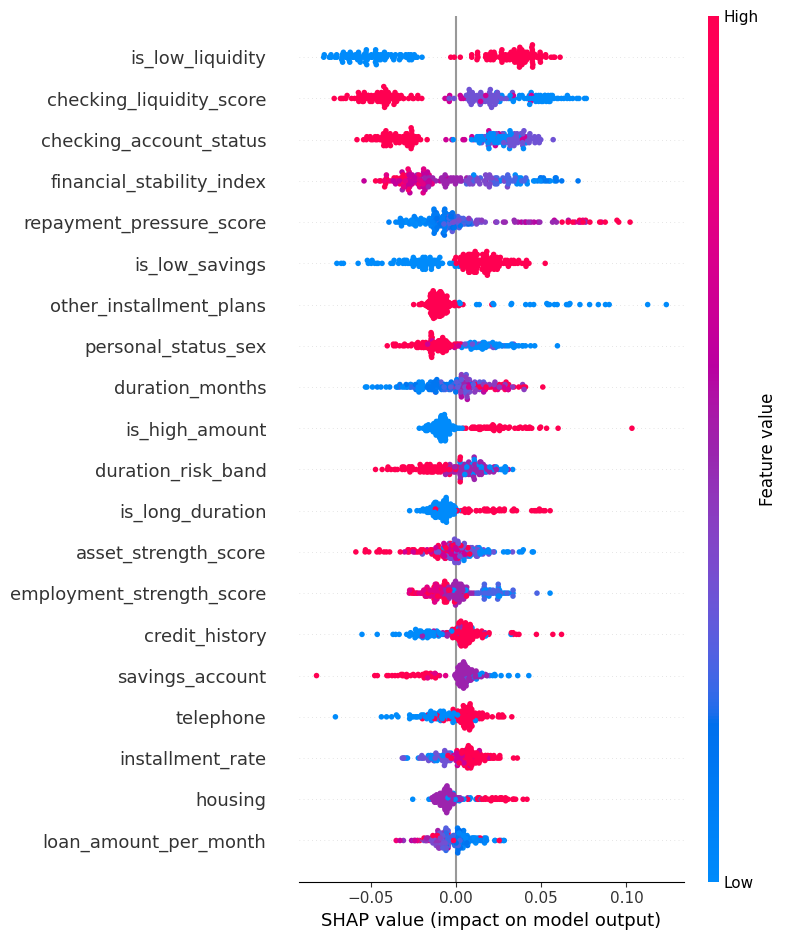

In [19]:
# SHAP Global Summary Plot for Bad Credit Prediction

shap.summary_plot(
    shap_values_bad_credit,
    X_test,
    feature_names=X_test.columns
)

In [20]:
# Top SHAP Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP Importance": np.abs(shap_values_bad_credit).mean(axis=0)
}).sort_values("Mean Absolute SHAP Importance", ascending=False)

feature_importance.head(15)

,Feature,Mean Absolute SHAP Importance
32,is_low_liquidity,0.040804
26,checking_liquidity_score,0.036508
0,checking_account_status,0.030838
28,financial_stability_index,0.025429
29,repayment_pressure_score,0.020334
33,is_low_savings,0.019940
13,other_installment_plans,0.016233
8,personal_status_sex,0.015852
1,duration_months,0.015456
30,is_high_amount,0.013895


## Explainable AI Interpretation using SHAP

SHAP analysis shows that the model's credit risk decisions are mainly driven by borrower liquidity and financial stability indicators.

The strongest contributors to Bad Credit prediction include:

- Low checking account liquidity,
- Weak financial stability index,
- High repayment pressure,
- Low savings strength,
- Longer loan duration,
- High loan amount indicators, and
- Credit history patterns.

This confirms that the model is not relying only on raw statistical patterns, but is learning financially meaningful risk signals aligned with real-world lending intuition.

In [21]:
# ============================================================
# Step 11: Responsible AI Fairness Audit
# ============================================================

fairness_df = X_test.copy()
fairness_df["actual"] = y_test.values
fairness_df["predicted_risk"] = (probs >= 0.30).astype(int)

# Bring original decoded sensitive-like attributes from df_fe
fairness_df["age_group_label"] = df_fe.loc[X_test.index, "age_group"].values
fairness_df["personal_status_sex_label"] = df_fe.loc[X_test.index, "personal_status_sex"].values
fairness_df["foreign_worker_label"] = df_fe.loc[X_test.index, "foreign_worker"].values

def fairness_summary(data, group_col):
    summary = data.groupby(group_col).agg(
        total_applicants=("actual", "count"),
        actual_bad_rate=("actual", "mean"),
        predicted_risk_rate=("predicted_risk", "mean")
    ).reset_index()

    return summary.sort_values("predicted_risk_rate", ascending=False)

age_fairness = fairness_summary(fairness_df, "age_group_label")
sex_fairness = fairness_summary(fairness_df, "personal_status_sex_label")
foreign_fairness = fairness_summary(fairness_df, "foreign_worker_label")

print("Age Group Fairness Summary")
display(age_fairness)

print("Personal Status / Sex Fairness Summary")
display(sex_fairness)

print("Foreign Worker Fairness Summary")
display(foreign_fairness)

Age Group Fairness Summary


,age_group_label,total_applicants,actual_bad_rate,predicted_risk_rate
3,Young Applicant,39,0.487179,0.794872
0,Early Career,66,0.333333,0.636364
2,Senior Applicant,32,0.187500,0.500000
1,Mid Career,63,0.206349,0.492063


Personal Status / Sex Fairness Summary


,personal_status_sex_label,total_applicants,actual_bad_rate,predicted_risk_rate
1,Male Divorced/Separated,9,0.333333,0.777778
2,Male Married/Widowed,12,0.250000,0.666667
0,Female Divorced/Married,61,0.327869,0.655738
3,Male Single,118,0.288136,0.550847


Foreign Worker Fairness Summary


,foreign_worker_label,total_applicants,actual_bad_rate,predicted_risk_rate
1,Yes,194,0.304124,0.613402
0,No,6,0.166667,0.166667


## Responsible AI Fairness Audit

A fairness inspection was conducted across age category, personal status/sex category, and foreign worker status using the optimized 0.30 lending threshold.

Key findings:

- Younger applicants were flagged as risky at substantially higher rates,
- Certain personal-status borrower groups also exhibited elevated model risk assignment,
- Foreign worker subgroup analysis was inconclusive due to severe sample imbalance.

These results highlight that while predictive performance is strong, operational deployment would require continuous fairness surveillance to ensure that model conservatism does not unintentionally produce disproportionate borrower exclusion across demographic groups.

In [22]:
# ============================================================
# Step 12: Save Deployment Artifacts
# ============================================================

import joblib

joblib.dump(brf, "balanced_random_forest_credit_model.pkl")
joblib.dump(scaler, "credit_scaler.pkl")
joblib.dump(label_encoders, "credit_label_encoders.pkl")

print("Deployment files saved successfully.")

Deployment files saved successfully.


In [23]:
# ============================================================
# Step 13: Save Feature Column Order
# ============================================================

joblib.dump(list(X.columns), "feature_columns.pkl")

print("Feature columns saved successfully.")
print("Number of features:", len(X.columns))

Feature columns saved successfully.
Number of features: 34


In [24]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load files
model = joblib.load("balanced_random_forest_credit_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

st.set_page_config(page_title="AI Credit Risk Intelligence System", layout="wide")

st.title("AI Credit Risk Intelligence System")
st.write("Loan default risk prediction with cost-sensitive banking intelligence.")

st.sidebar.header("Applicant Details")

duration_months = st.sidebar.slider("Loan Duration (months)", 6, 72, 24)
credit_amount = st.sidebar.number_input("Credit Amount", min_value=250, max_value=20000, value=3000)
age = st.sidebar.slider("Applicant Age", 18, 75, 35)

installment_rate = st.sidebar.slider("Installment Rate", 1, 4, 2)
present_residence_since = st.sidebar.slider("Present Residence Since", 1, 4, 2)
existing_credits = st.sidebar.slider("Existing Credits", 1, 4, 1)
people_liable = st.sidebar.slider("People Liable", 1, 2, 1)

checking_liquidity_score = st.sidebar.slider("Checking Liquidity Score", 0, 3, 1)
savings_strength_score = st.sidebar.slider("Savings Strength Score", 0, 3, 1)
employment_strength_score = st.sidebar.slider("Employment Strength Score", 0, 4, 2)
asset_strength_score = st.sidebar.slider("Asset Strength Score", 0, 3, 1)

threshold = st.sidebar.slider("Risk Threshold", 0.10, 0.90, 0.30, 0.05)

loan_amount_per_month = credit_amount / duration_months

financial_stability_index = (
    employment_strength_score +
    savings_strength_score +
    checking_liquidity_score +
    asset_strength_score
)

repayment_pressure_score = (installment_rate * duration_months) / max(financial_stability_index, 1)

is_high_amount = int(credit_amount > 4000)
is_long_duration = int(duration_months > 24)
is_low_liquidity = int(checking_liquidity_score <= 1)
is_low_savings = int(savings_strength_score == 0)

input_data = pd.DataFrame(columns=feature_columns)
input_data.loc[0] = 0

manual_values = {
    "duration_months": duration_months,
    "credit_amount": credit_amount,
    "installment_rate": installment_rate,
    "present_residence_since": present_residence_since,
    "age": age,
    "existing_credits": existing_credits,
    "people_liable": people_liable,
    "loan_amount_per_month": loan_amount_per_month,
    "employment_strength_score": employment_strength_score,
    "savings_strength_score": savings_strength_score,
    "checking_liquidity_score": checking_liquidity_score,
    "asset_strength_score": asset_strength_score,
    "financial_stability_index": financial_stability_index,
    "repayment_pressure_score": repayment_pressure_score,
    "is_high_amount": is_high_amount,
    "is_long_duration": is_long_duration,
    "is_low_liquidity": is_low_liquidity,
    "is_low_savings": is_low_savings
}

for col, val in manual_values.items():
    if col in input_data.columns:
        input_data[col] = val

risk_probability = model.predict_proba(input_data)[0][1]
decision = "High Risk / Review Required" if risk_probability >= threshold else "Low Risk / Likely Approve"

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Predicted Default Risk", f"{risk_probability:.2%}")

with col2:
    st.metric("Decision Threshold", f"{threshold:.2f}")

with col3:
    st.metric("Decision", decision)

profile = pd.DataFrame({
    "Metric": [
        "Loan Amount per Month",
        "Financial Stability Index",
        "Repayment Pressure Score",
        "High Amount Flag",
        "Long Duration Flag",
        "Low Liquidity Flag",
        "Low Savings Flag"
    ],
    "Value": [
        round(loan_amount_per_month,2),
        financial_stability_index,
        round(repayment_pressure_score,2),
        is_high_amount,
        is_long_duration,
        is_low_liquidity,
        is_low_savings
    ]
})

st.dataframe(profile, width='stretch')
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [25]:
!ls -lh

total 18M
-rw-r--r-- 1 root root 3.8K Apr 26 03:45 app.py
-rw-r--r-- 1 root root  18M Apr 26 03:45 balanced_random_forest_credit_model.pkl
drwxr-xr-x 4 root root 4.0K Apr 26 03:43 catboost_info
-rw-r--r-- 1 root root 4.8K Apr 26 03:45 credit_label_encoders.pkl
-rw-r--r-- 1 root root 2.3K Apr 26 03:45 credit_scaler.pkl
-rw-r--r-- 1 root root  659 Apr 26 03:45 feature_columns.pkl
drwxr-xr-x 1 root root 4.0K Apr 26 03:41 sample_data


In [26]:
!cat streamlit.log

cat: streamlit.log: No such file or directory


In [27]:
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true > streamlit.log 2>&1 &

In [28]:
!ps -ef | grep streamlit

root        8650    7247  0 03:45 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root        8652    8650  0 03:45 ?        00:00:00 grep streamlit


In [29]:
!lt --port 8501

/bin/bash: line 1: lt: command not found


In [30]:
!zip -r AI-Credit-Risk-Intelligence-System.zip app.py balanced_random_forest_credit_model.pkl feature_columns.pkl credit_scaler.pkl credit_label_encoders.pkl german.data Credit_Risk_Intelligence_System.ipynb


	zip warning: name not matched: german.data
	zip warning: name not matched: Credit_Risk_Intelligence_System.ipynb
  adding: app.py (deflated 66%)
  adding: balanced_random_forest_credit_model.pkl (deflated 84%)
  adding: feature_columns.pkl (deflated 47%)
  adding: credit_scaler.pkl (deflated 33%)
  adding: credit_label_encoders.pkl (deflated 74%)


In [31]:
!ls


AI-Credit-Risk-Intelligence-System.zip	 credit_scaler.pkl
app.py					 feature_columns.pkl
balanced_random_forest_credit_model.pkl  sample_data
catboost_info				 streamlit.log
credit_label_encoders.pkl
